# 01 — Hill Climbing y Random Restart

**Curso:** Inteligencia Artificial — Optimización

Este notebook contiene ejemplos guiados y actividades para desarrollar en clase.

## Objetivos

Al finalizar este notebook podrás:

- representar un problema de optimización mediante estados, vecinos y una función objetivo;
- implementar **Hill Climbing** para un problema discreto;
- identificar óptimos locales y mesetas;
- usar **Random Restart** para mejorar la exploración.

En los notebooks nos concentraremos en experimentar. La formalización y las propiedades de los algoritmos se presentan en las diapositivas.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales. El costo de una solución es la suma de la distancia de cada casa al hospital más cercano.

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2)) = |r_1-r_2|+|c_1-c_2|
$$

El problema es

$$
\min_{H} \sum_{c\in C}\min_{h\in H}d(c,h)
$$

- $C$: conjunto de casas.
- $H$: conjunto de hospitales.
- Un vecino se obtiene moviendo un hospital una celda arriba, abajo, izquierda o derecha.

![HillClimbing](https://drive.google.com/uc?export=view&id=1Vb7q8PCqTw-8WkalRWqtB86ovmLhrU1r)


In [4]:
%pip install matplotlib

import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 4.9 MB/s eta 0:00:02
   ---------- ----------------------------- 2.4/9.3 MB 6.8 MB/s eta 0:00:02
   ------------------------- -------------- 6.0/9.3 MB 10.8 MB/s eta 0:00:01
   ------------------------------- -------- 7.3/9.3 MB 11.0 MB/s eta 0:00:01
   ----------------------------------- ---- 8.4/9.3 MB 8.8 MB/s eta 0:00:01
   -------------------------------------- - 8.9/9.3 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 7.0 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 14.5 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing]
   ---------------------------------------- 0/6 [pyparsing

In [5]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(min(manhattan(house, hospital) for hospital in hospitals)
               for house in houses)


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        hr, hc = zip(*houses)
        ax.scatter(hc, hr, marker='s', s=110, label='Casas')
    if hospitals:
        rr, cc = zip(*hospitals)
        ax.scatter(cc, rr, marker='P', s=180, label='Hospitales')

    ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f'Costo = {total_cost(houses, hospitals)}')
    plt.tight_layout()
    plt.show()

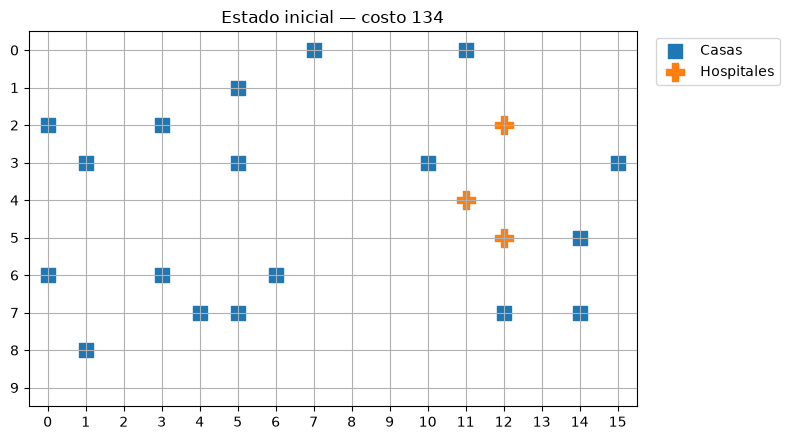

In [6]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [(r, c) for r in range(HEIGHT) for c in range(WIDTH)]
houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(random.sample(available, NUM_HOSPITALS))

plot_state(HEIGHT, WIDTH, houses, initial_hospitals,
           title=f'Estado inicial — costo {total_cost(houses, initial_hospitals)}')

## 2. Vecindario

Para generar estados vecinos moveremos **un hospital a la vez** hacia una celda adyacente disponible.

In [7]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue
            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors

neighbors = neighbors_of_state(HEIGHT, WIDTH, houses, initial_hospitals)
print('Número de vecinos:', len(neighbors))
print('Costo actual:', total_cost(houses, initial_hospitals))
print('Mejor costo vecino:', min(total_cost(houses, n) for n in neighbors))

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing

En cada iteración:

1. generamos todos los vecinos;
2. calculamos sus costos;
3. nos movemos al vecino con menor costo;
4. detenemos el proceso cuando ningún vecino mejora la solución.

Costo inicial: 134
Costo final: 62
Iteraciones con mejora: 13


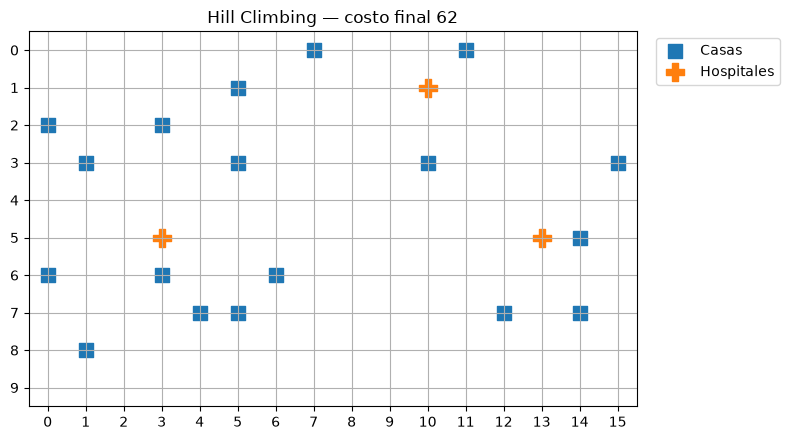

In [8]:
def hill_climbing(height, width, houses, num_hospitals, initial_state=None,
                  max_iterations=200, rng=None):
    rng = rng or random.Random()
    available = list(set((r, c) for r in range(height) for c in range(width)) - houses)
    current = set(initial_state) if initial_state is not None else set(rng.sample(available, num_hospitals))
    history = [total_cost(houses, current)]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(height, width, houses, current)
        if not neighbors:
            break

        costs = [total_cost(houses, n) for n in neighbors]
        best_cost = min(costs)
        current_cost = history[-1]

        if best_cost >= current_cost:
            break

        best_neighbors = [n for n, c in zip(neighbors, costs) if c == best_cost]
        current = set(rng.choice(best_neighbors))
        history.append(best_cost)
        states.append(set(current))

    return current, history, states

solution, history, states = hill_climbing(
    HEIGHT, WIDTH, houses, NUM_HOSPITALS,
    initial_state=initial_hospitals,
    rng=random.Random(SEED)
)

print('Costo inicial:', history[0])
print('Costo final:', history[-1])
print('Iteraciones con mejora:', len(history) - 1)
plot_state(HEIGHT, WIDTH, houses, solution,
           title=f'Hill Climbing — costo final {history[-1]}')

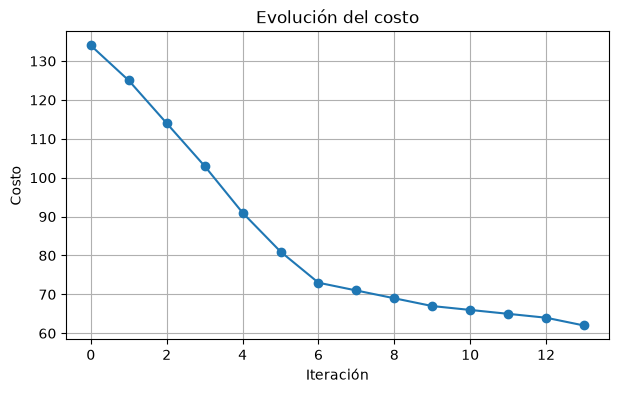

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(range(len(history)), history, marker='o')
plt.xlabel('Iteración')
plt.ylabel('Costo')
plt.title('Evolución del costo')
plt.grid(True)
plt.show()

## 4. Random Restart

Una corrida de Hill Climbing puede terminar en un óptimo local. Random Restart ejecuta el algoritmo desde diferentes estados iniciales y conserva la mejor solución encontrada.

Mejor costo: 56
Reinicio ganador: 2


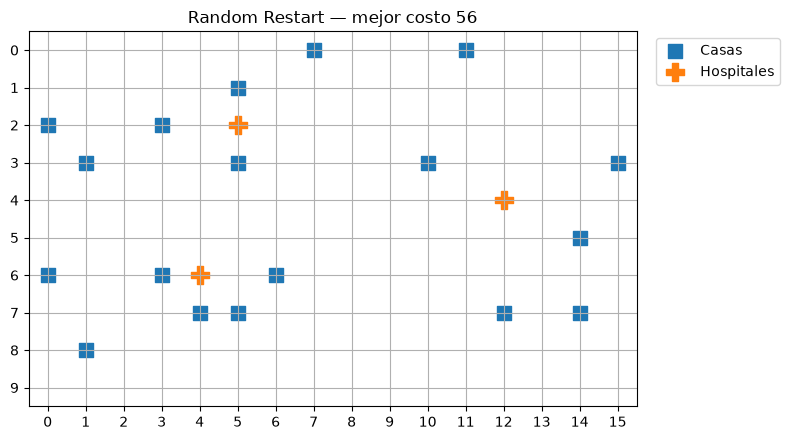

In [ ]:
def random_restart(height, width, houses, num_hospitals, restarts=30, seed=0):
    master_rng = random.Random(seed)
    runs = []
    best = None

    for restart in range(restarts):
        run_seed = master_rng.randrange(10**9)
        solution, history, _ = hill_climbing(
            height, width, houses, num_hospitals,
            rng=random.Random(run_seed)
        )
        record = {
            'restart': restart,
            'solution': solution,
            'initial_cost': history[0],
            'final_cost': history[-1],
            'iterations': len(history) - 1
        }
        runs.append(record)
        if best is None or record['final_cost'] < best['final_cost']:
            best = record

    return best, runs

best, runs = random_restart(HEIGHT, WIDTH, houses, NUM_HOSPITALS, restarts=40, seed=SEED)
print('Mejor costo:', best['final_cost'])
print('Reinicio ganador:', best['restart'])
plot_state(HEIGHT, WIDTH, houses, best['solution'],
           title=f'Random Restart — mejor costo {best["final_cost"]}')

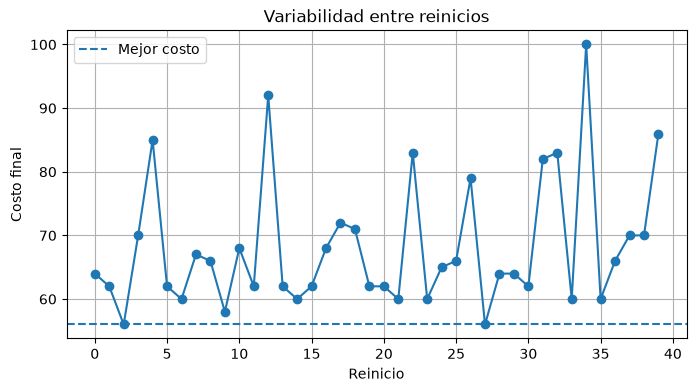

In [11]:
final_costs = [run['final_cost'] for run in runs]
plt.figure(figsize=(8, 4))
plt.plot(final_costs, marker='o')
plt.axhline(min(final_costs), linestyle='--', label='Mejor costo')
plt.xlabel('Reinicio')
plt.ylabel('Costo final')
plt.title('Variabilidad entre reinicios')
plt.legend()
plt.grid(True)
plt.show()

## Actividades

### Actividad 1 — Distancia euclídea

Modifica la función de costo para usar

$$
d(a,b)=\sqrt{(a_r-b_r)^2+(a_c-b_c)^2}
$$

Compara la ubicación de los hospitales y el costo con la distancia Manhattan.

In [16]:
# TODO: implementa la distancia euclídea y una nueva función de costo.
def euclidean(a, b):
    return np.sqrt((a[0] - b[0])**2 + (a[1] - b[1])**2)


def total_cost_euclidean(houses, hospitals):
    total = 0

    for house in houses:
        distances = [euclidean(house, hospital) for hospital in hospitals]
        total += min(distances)

    return total

### Actividad 2 — Número de hospitales

Ejecuta Random Restart para $k\in\{1,2,3,4,5\}$. Registra el mejor costo y discute si agregar hospitales produce siempre la misma reducción.

In [19]:
# TODO: completa el experimento.
results = []

for k in range(1, 6):
    best_k, _ = random_restart(
        HEIGHT,
        WIDTH,
        houses,
        k,
        restarts=40,
        seed=SEED
    )

    results.append((k, best_k["final_cost"]))

results

[(1, 114), (2, 76), (3, 56), (4, 46), (5, 38)]

### Actividad 3 — Diseño del vecindario

Actualmente un hospital solo se mueve una celda. Crea un vecindario que permita movimientos de hasta dos celdas. ¿Mejora el resultado? ¿Cuánto aumenta el número de vecinos evaluados?

In [21]:
### Actividad 3 — Diseño del vecindario

def neighbors_of_state_two_steps(height, width, houses, hospitals):
    neighbors = []

    # Movimientos de hasta dos celdas
    moves = [
        (-2, 0), (-1, 0),
        (1, 0), (2, 0),
        (0, -2), (0, -1),
        (0, 1), (0, 2)
    ]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (hospital[0] + dr, hospital[1] + dc)

            # Verificar que esté dentro del tablero
            if not (0 <= candidate[0] < height and 0 <= candidate[1] < width):
                continue

            # No permitir hospitales sobre casas ni sobre otros hospitales
            if candidate in houses or candidate in hospitals:
                continue

            # Crear nuevo estado
            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)

            neighbors.append(new_state)

    return neighbors


# Generar vecinos usando movimientos de hasta dos celdas
neighbors_two_steps = neighbors_of_state_two_steps(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals
)

# Calcular resultados
current_cost = total_cost(houses, initial_hospitals)
best_neighbor_cost = min(
    total_cost(houses, neighbor)
    for neighbor in neighbors_two_steps
)

print("Número de vecinos:", len(neighbors_two_steps))
print("Costo actual:", current_cost)
print("Mejor costo vecino:", best_neighbor_cost)
print("Mejora:", current_cost - best_neighbor_cost)

Número de vecinos: 22
Costo actual: 134
Mejor costo vecino: 114
Mejora: 20


## Preguntas de cierre

1. ¿Por qué Hill Climbing no necesita construir todo el espacio de búsqueda?

Hill Climbing no necesita construir todo el espacio de búsqueda porque explora únicamente los vecinos del estado actual. En cada iteración evalúa las soluciones cercanas y se mueve hacia una que mejore el costo. Por esto, utiliza menos memoria y evita explorar soluciones que no son necesarias para continuar la búsqueda.

2. ¿El resultado depende del estado inicial?

Sí. **Hill Climbing depende del estado inicial**, porque comienza la búsqueda desde una solución específica y solo se mueve hacia estados vecinos que mejoran la solución actual. Por esta razón, diferentes estados iniciales pueden llevar a diferentes soluciones finales, incluyendo óptimos locales.

3. ¿Random Restart garantiza encontrar el óptimo global?

No. **Random Restart no garantiza encontrar el óptimo global**. Al ejecutar Hill Climbing desde diferentes estados iniciales aumenta la probabilidad de encontrar una solución mejor y de escapar de algunos óptimos locales, pero no asegura que uno de los reinicios llegue al óptimo global.

4. ¿Qué información se pierde al conservar únicamente el mejor vecino?

Se pierde la información sobre los demás vecinos evaluados y sobre las posibles rutas que podrían haber llevado a mejores soluciones posteriormente. Al conservar únicamente el mejor vecino, Hill Climbing descarta alternativas que podrían conducir a otras regiones del espacio de búsqueda y eventualmente a un óptimo global.